In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


In [2]:
# Load dataset
df = pd.read_csv("weather.csv")

# Preview
print(df.head(10))


   MinTemp  MaxTemp WindGustDir  WindGustSpeed  Humidity  Pressure  Temp  \
0      8.0     24.3          NW           30.0        29    1015.0  23.6   
1     14.0     26.9         ENE           39.0        36    1008.4  25.7   
2     13.7     23.4          NW           85.0        69    1007.2  20.2   
3     13.3     15.5          NW           54.0        56    1007.0  14.1   
4      7.6     16.1         SSE           50.0        49    1018.5  15.4   
5      6.2     16.9          SE           44.0        57    1021.7  14.8   
6      6.1     18.2          SE           43.0        47    1022.2  17.3   
7      8.3     17.0           E           41.0        57    1024.2  15.5   
8      8.8     19.5           S           48.0        48    1022.7  18.9   
9      8.4     22.8           E           31.0        32    1020.7  21.7   

  RainTomorrow  
0          Yes  
1          Yes  
2          Yes  
3          Yes  
4           No  
5           No  
6           No  
7           No  
8         

In [3]:
print(df.describe())

          MinTemp     MaxTemp  WindGustSpeed    Humidity     Pressure  \
count  366.000000  366.000000     364.000000  366.000000   366.000000   
mean     7.265574   20.550273      39.840659   44.519126  1016.810383   
std      6.025800    6.690516      13.059807   16.850947     6.469422   
min     -5.300000    7.600000      13.000000   13.000000   996.800000   
25%      2.300000   15.025000      31.000000   32.250000  1012.800000   
50%      7.450000   19.650000      39.000000   43.000000  1017.400000   
75%     12.500000   25.500000      46.000000   55.000000  1021.475000   
max     20.900000   35.800000      98.000000   96.000000  1033.200000   

             Temp  
count  366.000000  
mean    19.230874  
std      6.640346  
min      5.100000  
25%     14.150000  
50%     18.550000  
75%     24.000000  
max     34.500000  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        366 non-null    float64
 1   MaxTemp        366 non-null    float64
 2   WindGustDir    363 non-null    object 
 3   WindGustSpeed  364 non-null    float64
 4   Humidity       366 non-null    int64  
 5   Pressure       366 non-null    float64
 6   Temp           366 non-null    float64
 7   RainTomorrow   366 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 23.0+ KB
None


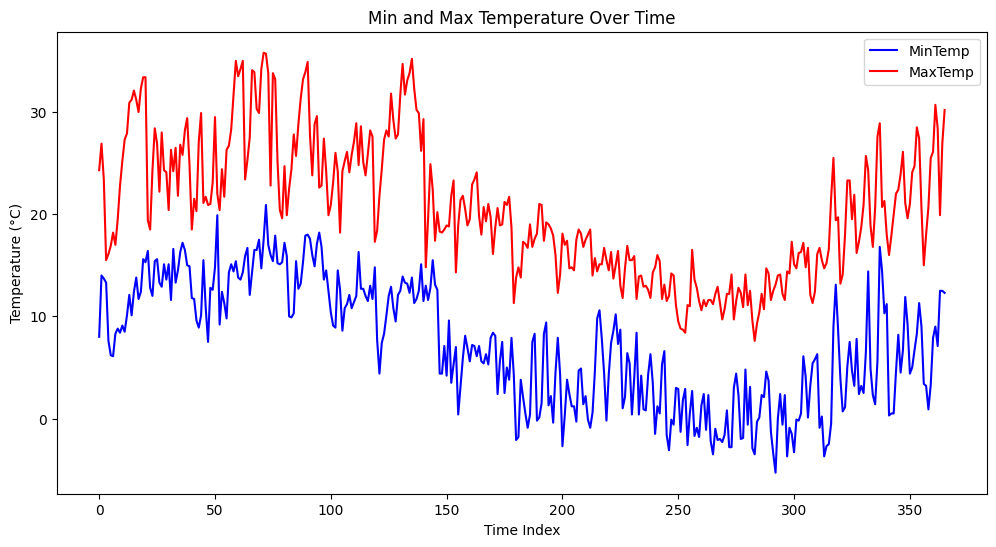

In [5]:
# Line plot of Min and Max Temperature
plt.figure(figsize=(12,6))
plt.plot(df['MinTemp'], label='MinTemp', color='blue')
plt.plot(df['MaxTemp'], label='MaxTemp', color='red')
plt.title('Min and Max Temperature Over Time')
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

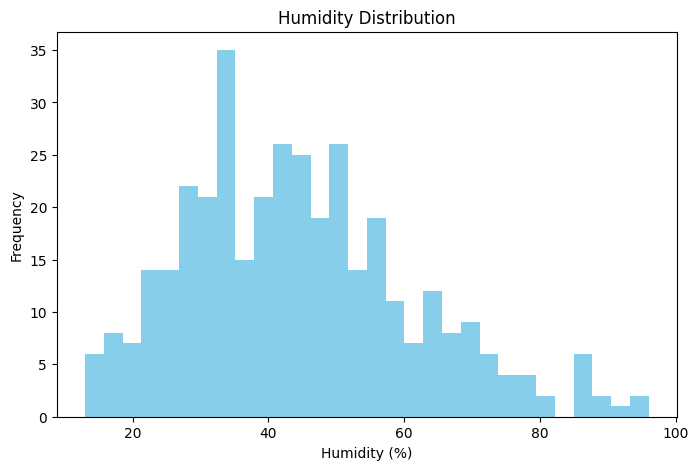

In [6]:
# Histogram of Humidity
plt.figure(figsize=(8,5))
plt.hist(df['Humidity'].dropna(), bins=30, color='skyblue')
plt.title('Humidity Distribution')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.show()

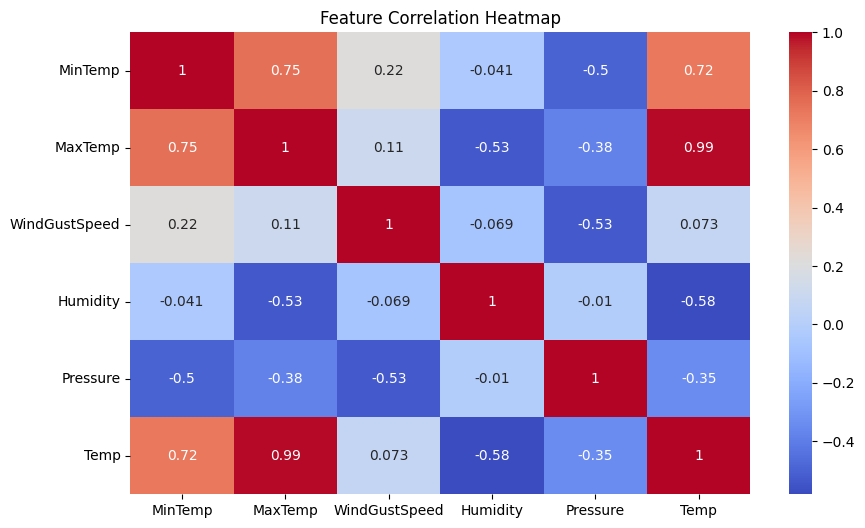

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['MinTemp','MaxTemp','WindGustSpeed','Humidity','Pressure','Temp']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

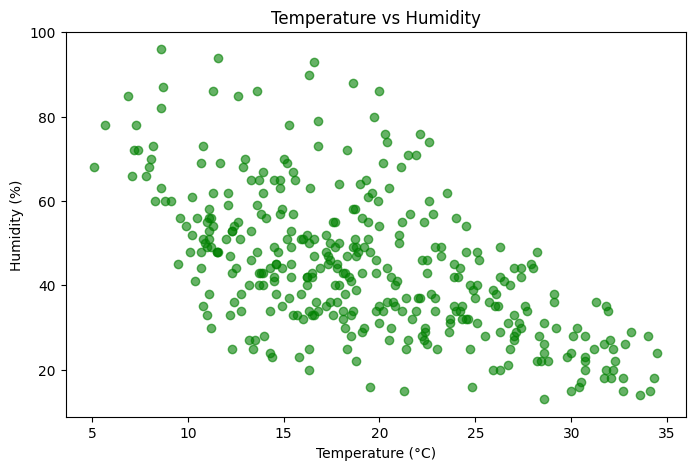

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['Temp'], df['Humidity'], alpha=0.6, color='green')
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()

In [9]:


# Create lag features
df['Temp_lag1'] = df['Temp'].shift(1)
df['Temp_lag2'] = df['Temp'].shift(2)





In [10]:
df.dropna(inplace=True)


In [11]:
X = df[['Temp_lag1','Temp_lag2']]
y = df['Temp']






In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [13]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
# Predict
predictions = model.predict(X_test)

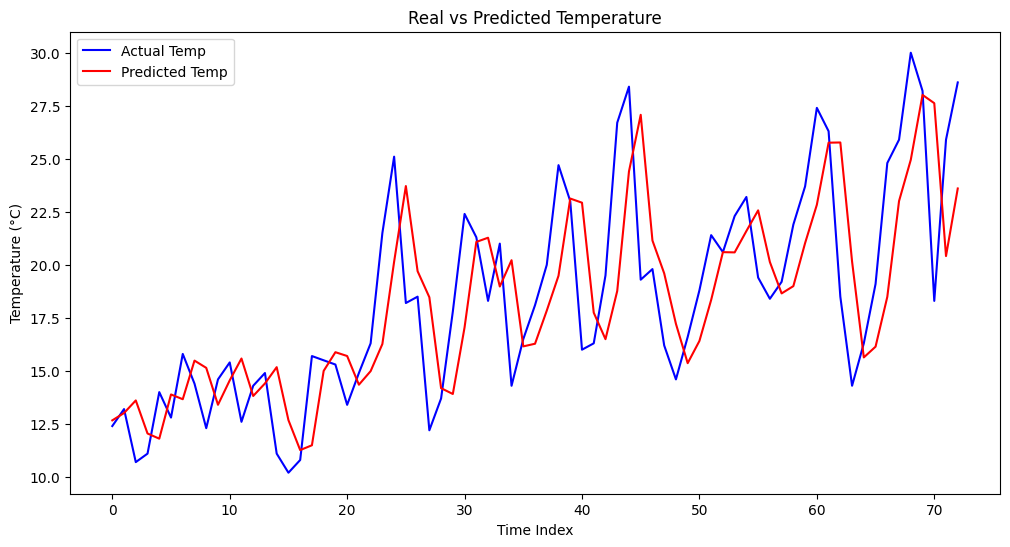

In [15]:
# Plot real vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Temp', color='blue')
plt.plot(predictions, label='Predicted Temp', color='red')
plt.title('Real vs Predicted Temperature')
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [16]:
# Evaluation
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.8136071059729995


/tmp/ipykernel_6992/490430245.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rain_counts.index, y=rain_counts.values, palette='viridis')


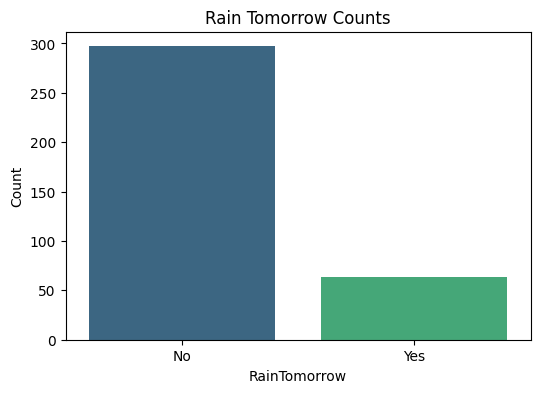

In [17]:
rain_counts = df['RainTomorrow'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=rain_counts.index, y=rain_counts.values, palette='viridis')
plt.title('Rain Tomorrow Counts')
plt.xlabel('RainTomorrow')
plt.ylabel('Count')
plt.show()

In [18]:
import requests
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import datetime,timedelta
import pytz

In [19]:
API_KEY='51766378512ce4d2b853b45e07f4e3b0'
BASE_URL='https://api.openweathermap.org/data/2.5/'

In [20]:
def get_current_weather(city):
  url=f"{BASE_URL}weather?q={city}&appid={API_KEY}&units=metric"
  response=requests.get(url)
  data=response.json()
  return{
      'city':data['name'],
      'current_temp':round(data['main']['temp']),
      'feels_like':round(data['main']['feels_like']),
      'temp_min':round(data['main']['temp_min']),
      'temp_max':round(data['main']['temp_max']),
      'humidity':round(data['main']['humidity']),
      'description':data['weather'][0]['description'],
      'country':data['sys']['country'],
      'wind_gust_dir':data['wind']['deg'],
      'pressure':data['main']['pressure'],
      'Wind_Gust_Speed':data['wind']['speed']

  }

In [21]:
def read_historical_data(filename):
  df=pd.read_csv(filename)
  df=df.dropna()
  df=df.drop_duplicates()
  return df

In [22]:
def prepare_data(data):
  le=LabelEncoder()
  data['WindGustDir']=le.fit_transform(data['WindGustDir'])
  data['RainTomorrow']=le.fit_transform(data['RainTomorrow'])
  X=data[['MinTemp','MaxTemp','WindGustDir','WindGustSpeed','Humidity','Pressure','Temp']]
  y=data['RainTomorrow']
  return X,y,le

In [23]:
def train_rain_model(X,y):
  X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
  model=RandomForestClassifier(n_estimators=100,random_state=42)
  model.fit(X_train,y_train)

  y_pred=model.predict(X_test)

  print("mean squared error for rain model")

  print(mean_squared_error(y_test,y_pred))
  return model

In [24]:
def prepare_regression_data(data,feature):
  X,y=[],[]
  for i in range(len(data)-1):
    X.append(data[feature].iloc[i])
    y.append(data[feature].iloc[i+1])
  X=np.array(X).reshape(-1,1)
  y=np.array(y)
  return X,y

In [25]:
def train_regression_model(X,y):
  model=RandomForestRegressor(n_estimators=100,random_state=42)
  model.fit(X,y)
  return model

In [26]:
def predict_future(model,current_value):
  predictions=[current_value]

  for i in range(5):
    next_value=model.predict(np.array([[predictions[-1]]]))

    predictions.append(next_value[0])

  return predictions[1:]

In [27]:
def weather_view():
  city=input('enter any city name:')
  current_weather=get_current_weather(city)

  historical_data=read_historical_data('/content/weather.csv')

  X,y,le=prepare_data(historical_data)

  rain_model=train_rain_model(X,y)
  wind_deg=current_weather['wind_gust_dir']%360
  compass_points=[
      ("N",0,11.25),("NNE",11.25,33.75),("NE",33.75,56.25),("ENE",56.25,78.75),
      ("E",78.75,101.25),("ESE",101.25,123.75),("SE",123.75,146.25),
      ("SSE",146.25,168.75),("S",168.75,191.25),("SSW",191.25,281.25),
      ("SW",213.75,236.25),("WSW",236.25,258.75),("W",258.75,281.25),
      ("WNW",281.25,303.75),("NW",303.75,326.25),("NNW",326.25,348.75)
  ]
  compass_direction=next(point for point,start,end in compass_points if start <= wind_deg < end)

  compass_direction_encoded=le.transform([compass_direction])[0] if compass_direction in le.classes_ else -1


  current_data={
      'MinTemp':current_weather['temp_min'],
      'MaxTemp':current_weather['temp_max'],
      'WindGustDir':compass_direction_encoded,
      'WindGustSpeed':current_weather['Wind_Gust_Speed'],
      'Humidity':current_weather['humidity'],
      'Pressure':current_weather['pressure'],
      'Temp':current_weather['current_temp'],
  }

  current_df=pd.DataFrame([current_data])

  rain_prediction=rain_model.predict(current_df)[0]

  X_temp,y_temp=prepare_regression_data(historical_data,'Temp')
  X_hum,y_hum=prepare_regression_data(historical_data,'Humidity')

  temp_model=train_regression_model(X_temp,y_temp)
  hum_model=train_regression_model(X_hum,y_hum)

  future_temp=predict_future(temp_model,current_weather['temp_min'])
  future_humidity=predict_future(hum_model,current_weather['humidity'])

  timezone=pytz.timezone('Asia/Karachi')
  now=datetime.now(timezone)
  next_hour=now+timedelta(hours=1)
  next_hour=next_hour.replace(minute=0,second=0,microsecond=0)

  future_times=[(next_hour+timedelta(hours=i)).strftime("%H:00") for i in range(5)]

  print(f"city: {city},{current_weather['country']}")
  print(f"current Temperature:{current_weather['current_temp']}")
  print(f"feels like:{current_weather['feels_like']}")
  print(f"Minimum Temperature:{current_weather['temp_min']}°C")
  print(f"Maximum Temperature:{current_weather['temp_max']}°C")
  print(f"Humidity:{current_weather['humidity']}%")
  print(f"Weather Prediction:{current_weather['description']}")
  print(f"Rain Prediction:{'Yes' if rain_prediction else 'No'}")

  print("/nFuture Temperature Prediction:")
  for time, temp in zip(future_times,future_temp):
    print(f"{time}:{round(temp,1)}°C")

  print("/nfuture Humidity prediction:")
  for time,humidity in zip(future_times,future_humidity):
    print(f"{time}:{round(humidity,1)}%")
weather_view()

enter any city name:bangalore
mean squared error for rain model
0.1506849315068493
city: bangalore,IN
current Temperature:28
feels like:29
Minimum Temperature:28°C
Maximum Temperature:29°C
Humidity:51%
Weather Prediction:few clouds
Rain Prediction:Yes
/nFuture Temperature Prediction:
22:00:27.7°C
23:00:22.8°C
00:00:25.4°C
01:00:24.7°C
02:00:23.4°C
/nfuture Humidity prediction:
22:00:46.6%
23:00:47.2%
00:00:47.2%
01:00:47.2%
02:00:47.2%
